In [12]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load the raw Titanic dataset

df = pd.read_csv("Titanic-Dataset.csv")

In [14]:
# Create a working copy

df_clean = df.copy()

In [15]:
# View the first 5 rows

df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
# Check the shape of the dataset

df_clean.shape

(891, 12)

In [17]:
# Check column names

df_clean.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [18]:
# Check basic dataset information

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [19]:
# Get a statistical summary

df_clean.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
# Check data types

df_clean.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [21]:
# Check missing values

df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
# Check duplicate rows

df_clean.duplicated().sum()

np.int64(0)

In [23]:
# Count unique values in every column

df_clean.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [24]:
# Check unique values in important categorical columns

print(df_clean["Sex"].unique())
print(df_clean["Embarked"].unique())
print(df_clean["Pclass"].unique())
print(df_clean["Survived"].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
[3 1 2]
[0 1]


In [25]:
# Analyze the Age column before filling missing values

df_clean["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

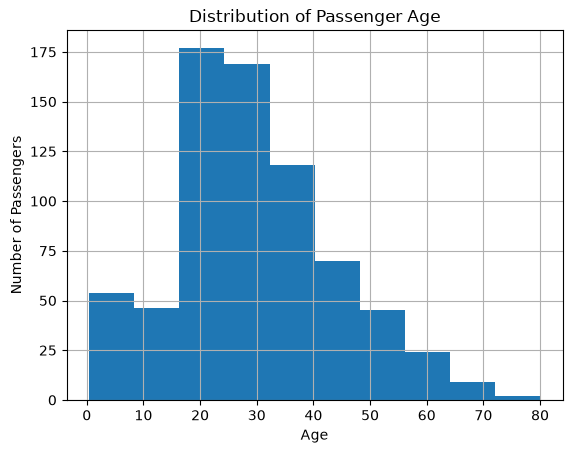

In [26]:
# Visualize the Age distribution


df_clean["Age"].hist()

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Age")

plt.show()

In [27]:
# Compare Age mean and median

print("Mean Age:", df_clean["Age"].mean())
print("Median Age:", df_clean["Age"].median())

Mean Age: 29.69911764705882
Median Age: 28.0


In [28]:
# Fill missing Age values

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [29]:
# Check the Embarked column

df_clean["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [30]:
# Find the most common Embarked value

df_clean["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [31]:
# Fill missing Embarked values

df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)

In [32]:
# Investigate missing Cabin values

missing_cabin = df_clean["Cabin"].isnull().sum()
total_rows = len(df_clean)

missing_percentage = (missing_cabin / total_rows) * 100

print("Missing Cabin values:", missing_cabin)
print("Missing Cabin percentage:", missing_percentage)

Missing Cabin values: 687
Missing Cabin percentage: 77.10437710437711


In [33]:
# Extract Deck from Cabin

df_clean["Deck"] = df_clean["Cabin"].str[0]

In [34]:
# Represent missing Deck information as Unknown

df_clean["Deck"] = df_clean["Deck"].fillna("Unknown")

In [35]:
# Check Deck categories

df_clean["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [36]:
# Remove the original Cabin column

df_clean = df_clean.drop("Cabin", axis=1)

In [37]:
# Verify remaining missing values

df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64

In [38]:
# Check duplicates after cleaning

df_clean.duplicated().sum()

np.int64(0)

In [39]:
# Check the cleaned dataset structure

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  Deck         891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [40]:
# Create FamilySize

df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

In [41]:
# Create IsAlone

df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

In [42]:
# Extract Title from Name

df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^.]*)\.")

In [43]:
# Check Title categories

df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [44]:
# Check repeated Ticket values

df_clean["Ticket"].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

In [45]:
# Analyze overall survival

df_clean["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [46]:
# Calculate survival percentage

df_clean["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [47]:
# Compare survival by Sex

df_clean.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [48]:
# Compare survival by Pclass

df_clean.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [49]:
# Compare survival by Embarked

df_clean.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

In [50]:
# Compare survival by Deck

df_clean.groupby("Deck")["Survived"].mean()

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

In [51]:
# Compare survival by FamilySize

df_clean.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

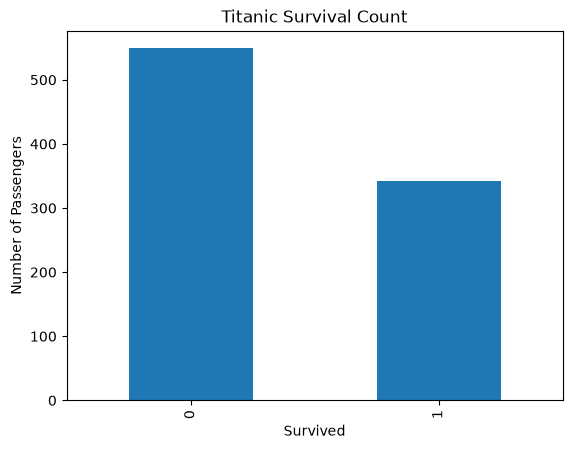

In [52]:
# Visualize survival counts

df_clean["Survived"].value_counts().plot(kind="bar")

plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.title("Titanic Survival Count")

plt.show()

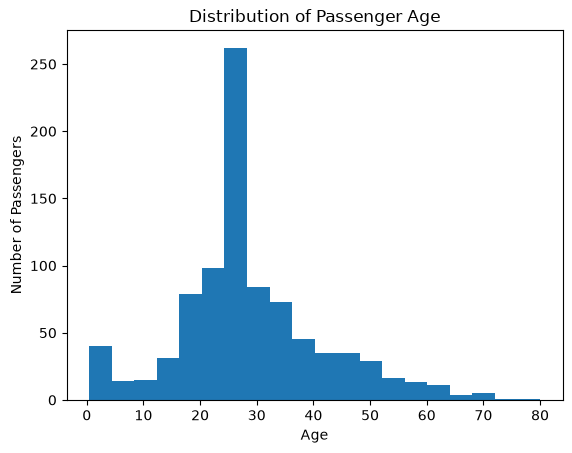

In [53]:
# Visualize Age distribution

plt.hist(df_clean["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Age")

plt.show()

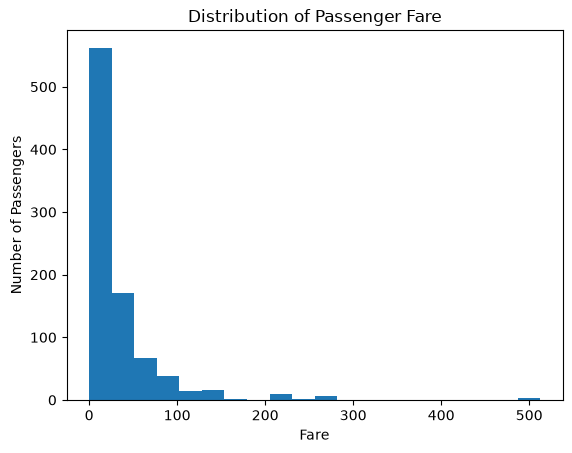

In [54]:
# Visualize Fare distribution

plt.hist(df_clean["Fare"], bins=20)

plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Passenger Fare")

plt.show()

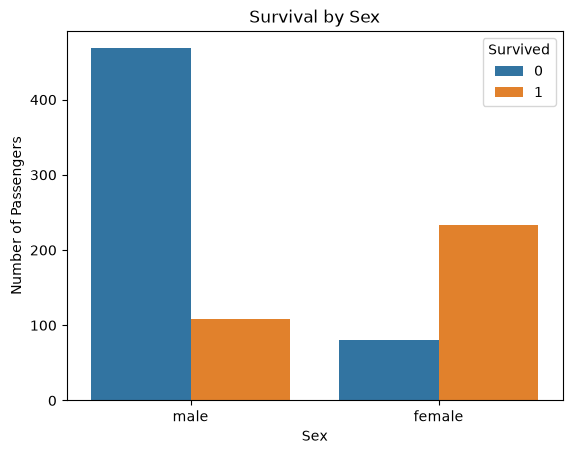

In [55]:
# Visualize survival by Sex

sns.countplot(data=df_clean, x="Sex", hue="Survived")

plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.title("Survival by Sex")

plt.show()

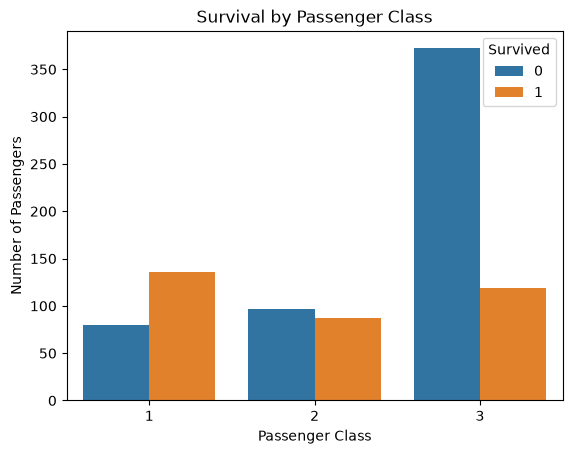

In [56]:
# Visualize survival by Pclass

sns.countplot(data=df_clean, x="Pclass", hue="Survived")

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Survival by Passenger Class")

plt.show()

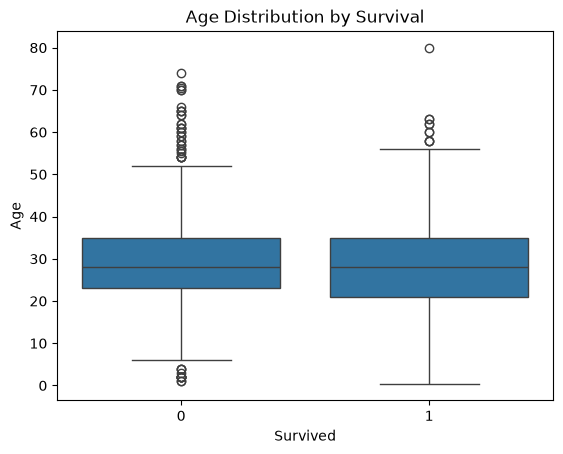

In [57]:
# Compare Age distributions by Survival

sns.boxplot(data=df_clean, x="Survived", y="Age")

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Age Distribution by Survival")

plt.show()

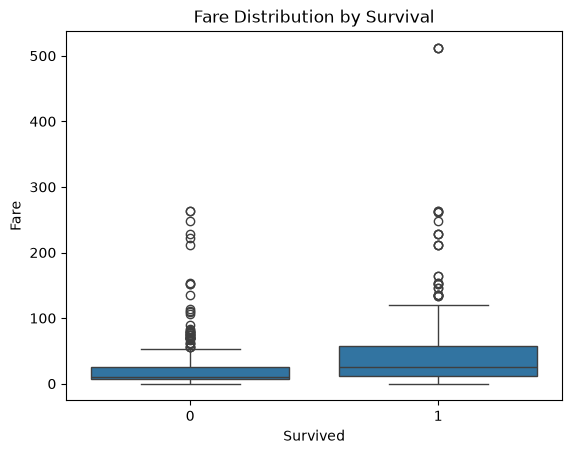

In [58]:
# Compare Fare distributions by Survival

sns.boxplot(data=df_clean, x="Survived", y="Fare")

plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival")

plt.show()

In [59]:
# Analyze Survival by Sex and Pclass

df_clean.groupby(["Sex", "Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [60]:
# Check numerical correlations

df_clean.select_dtypes(include="number").corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143,0.057462
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639,-0.203367
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997,0.135207
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619,0.171647
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712,-0.584471
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111,-0.583398
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138,-0.271832
FamilySize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000,-0.690922
IsAlone,0.057462,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,-0.690922,1.000000


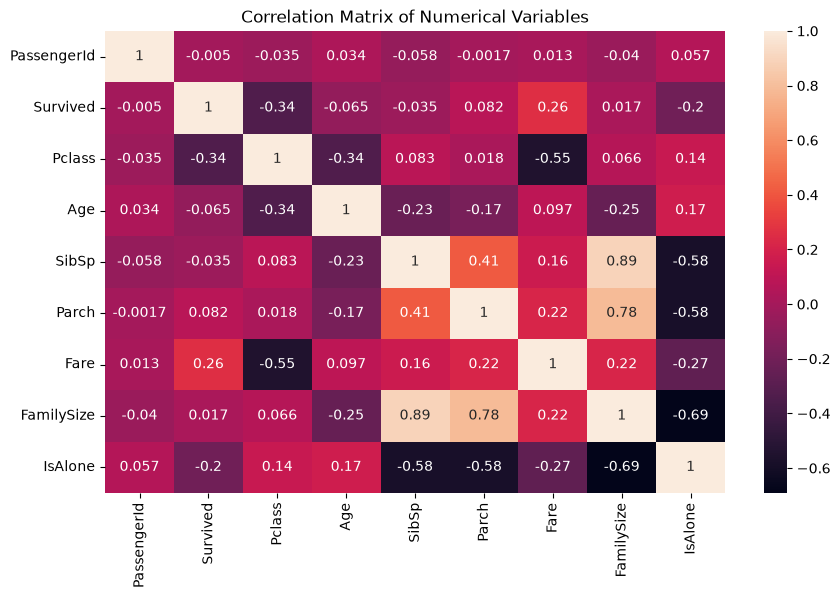

In [61]:
# Visualize correlations

plt.figure(figsize=(10, 6))

sns.heatmap(
    df_clean.select_dtypes(include="number").corr(),
    annot=True
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [62]:
# Check final dataset shape

df_clean.shape

(891, 15)

In [63]:
# Final dataset information

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  Deck         891 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
 14  Title        891 non-null    str    
dtypes: float64(2), int64(7), str(6)
memory usage: 104.5 KB


In [64]:
# Save the cleaned dataset

df_clean.to_csv("titanic_cleaned.csv", index=False)